
VisionFM per-class metrics (final epoch) over 3 folds [%]:

              Accuracy Balanced Accuracy        Dice         IoU
Background  99.29±0.17        87.47±0.07  99.63±0.09  99.27±0.18
IRF         96.56±2.96        88.95±2.22  80.53±1.83  76.77±1.92
SRF         95.25±3.08        90.52±4.84  86.95±6.27  84.37±7.26
PED         95.47±5.14        89.16±5.66  83.62±6.18  81.52±6.18


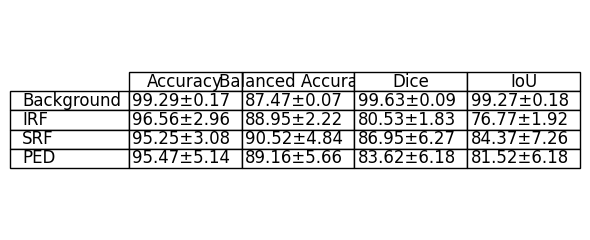

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

classes     = ["background", "IRF", "SRF", "PED"]
index_names = ["Background", "IRF", "SRF", "PED"]

# Fold 0
records0 = []
with open("results/oct_seg_e100_metrics_fold_0/log.txt", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records0.append(json.loads(line))
df0   = pd.DataFrame(records0)
last0 = df0.loc[df0["epoch"].idxmax()]

acc0  = [ last0[f"test_acc_{cls}"]  * 100 for cls in classes ]
bacc0 = [ last0[f"test_bacc_{cls}"] * 100 for cls in classes ]
dice0 = [ last0[f"test_dice_{cls}"] * 100 for cls in classes ]
iou0  = [ last0[f"test_iou_{cls}"]  * 100 for cls in classes ]

# Fold 1
records1 = []
with open("results/oct_seg_e100_metrics_fold_0/oct_seg_e100_metrics_fold_1/log.txt", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records1.append(json.loads(line))
df1   = pd.DataFrame(records1)
last1 = df1.loc[df1["epoch"].idxmax()]

acc1  = [ last1[f"test_acc_{cls}"]  * 100 for cls in classes ]
bacc1 = [ last1[f"test_bacc_{cls}"] * 100 for cls in classes ]
dice1 = [ last1[f"test_dice_{cls}"] * 100 for cls in classes ]
iou1  = [ last1[f"test_iou_{cls}"]  * 100 for cls in classes ]

# Fold 2
records2 = []
with open("results/oct_seg_e100_metrics_fold_0/oct_seg_e100_metrics_fold_1/oct_seg_e100_metrics_fold_2/log.txt", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records2.append(json.loads(line))
df2   = pd.DataFrame(records2)
last2 = df2.loc[df2["epoch"].idxmax()]

acc2  = [ last2[f"test_acc_{cls}"]  * 100 for cls in classes ]
bacc2 = [ last2[f"test_bacc_{cls}"] * 100 for cls in classes ]
dice2 = [ last2[f"test_dice_{cls}"] * 100 for cls in classes ]
iou2  = [ last2[f"test_iou_{cls}"]  * 100 for cls in classes ]

# Stack metrics and compute mean & std
acc_arr  = np.vstack([acc0,  acc1,  acc2])
bacc_arr = np.vstack([bacc0, bacc1, bacc2])
dice_arr = np.vstack([dice0, dice1, dice2])
iou_arr  = np.vstack([iou0,  iou1,  iou2 ])

mean_acc  = acc_arr.mean(axis=0);  std_acc  = acc_arr.std(axis=0)
mean_bacc = bacc_arr.mean(axis=0); std_bacc = bacc_arr.std(axis=0)
mean_dice = dice_arr.mean(axis=0); std_dice = dice_arr.std(axis=0)
mean_iou  = iou_arr.mean(axis=0);  std_iou  = iou_arr.std(axis=0)

summary = pd.DataFrame({
    "Accuracy":          [f"{mean_acc[i]:.2f}±{std_acc[i]:.2f}"  for i in range(len(classes))],
    "Balanced Accuracy": [f"{mean_bacc[i]:.2f}±{std_bacc[i]:.2f}" for i in range(len(classes))],
    "Dice":              [f"{mean_dice[i]:.2f}±{std_dice[i]:.2f}" for i in range(len(classes))],
    "IoU":               [f"{mean_iou[i]:.2f}±{std_iou[i]:.2f}"   for i in range(len(classes))]
}, index=index_names)

# Print 3 fold summary
print("\nVisionFM per-class metrics (final epoch) over 3 folds [%]:\n")
print(summary.to_string())

# Try summary table
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")
tbl = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
plt.tight_layout()
plt.show()

In [ ]:
# pip install tabulate if not installed
from tabulate import tabulate

# Make the index header empty so the top‐left cell is blank
summary.index.name = ""

print("\nVisionFM per-class metrics (final epoch) over 3 folds [%]:\n")
print(tabulate(summary,
               headers="keys",   
               tablefmt="fancy_grid",
               showindex=True)) 


VisionFM per-class metrics (final epoch) over 3 folds [%]:

╒════════════╤════════════╤═════════════════════╤════════════╤════════════╕
│            │ Accuracy   │ Balanced Accuracy   │ Dice       │ IoU        │
╞════════════╪════════════╪═════════════════════╪════════════╪════════════╡
│ Background │ 99.29±0.17 │ 87.47±0.07          │ 99.63±0.09 │ 99.27±0.18 │
├────────────┼────────────┼─────────────────────┼────────────┼────────────┤
│ IRF        │ 96.56±2.96 │ 88.95±2.22          │ 80.53±1.83 │ 76.77±1.92 │
├────────────┼────────────┼─────────────────────┼────────────┼────────────┤
│ SRF        │ 95.25±3.08 │ 90.52±4.84          │ 86.95±6.27 │ 84.37±7.26 │
├────────────┼────────────┼─────────────────────┼────────────┼────────────┤
│ PED        │ 95.47±5.14 │ 89.16±5.66          │ 83.62±6.18 │ 81.52±6.18 │
╘════════════╧════════════╧═════════════════════╧════════════╧════════════╛


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import sys

# Add project roots to import path
project_root = "/storage1/fs1/linyingz/Active/xiaoyus"
if project_root not in sys.path:
    sys.path.insert(0, project_root)
visionfm_root = project_root + "/VisionFM"
if visionfm_root not in sys.path:
    sys.path.insert(0, visionfm_root)
print("Path now contains:", sys.path[:2])

import glob, numpy as np, torch
from PIL import Image
from IPython.display import display, HTML
import pingouin as pg

# Models and utils
from VisionFM.models.vision_transformer import vit_base
from VisionFM.models.unetr_head      import Unetr_Head
from VisionFM.evaluation.transforms import Compose, Resize, ToTensor, Normalize
from VisionFM.utils                  import load_pretrained_weights, get_stats

# Paths and hyperparameters
DATA_ROOT      = "RetouchData"
ENC_WEIGHTS    = "/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/VFM_OCT_weights.pth"
CHECKPOINT_DEC = "results/oct_seg_e100_metrics_fold_0/oct_seg_e100_metrics_fold_1/checkpoint_91_linear.pth"
INPUT_SIZE     = 512
PATCH_SIZE     = 16
NUM_LABELS     = 4
classes        = ['Background','IRF','SRF','PED']

# Encoder
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = vit_base(
    img_size=[INPUT_SIZE],
    patch_size=PATCH_SIZE,
    num_classes=0,
    use_mean_pooling=False
).to(device)
load_pretrained_weights(
    encoder, ENC_WEIGHTS, checkpoint_key="teacher",
    model_name="vit_base", patch_size=PATCH_SIZE
)
encoder.eval()

# Decoder
decoder = Unetr_Head(
    embed_dim=encoder.embed_dim,
    num_classes=NUM_LABELS,
    img_dim=INPUT_SIZE
).to(device)
ckpt = torch.load(CHECKPOINT_DEC, map_location="cpu")
state = {k.replace("module.",""):v for k,v in ckpt["state_dict"].items()}
decoder.load_state_dict(state)
decoder.eval()

# Transforms
mean, std = get_stats("OCT")
if isinstance(mean, (list, tuple)) and len(mean) == 3:
    mean, std = mean[0], std[0]

val_tf = Compose([
    Resize((INPUT_SIZE, INPUT_SIZE)),
    ToTensor(),               # [1,H,W]
    Normalize([mean], [std]),
])

# Fraction matrix helper
def compute_frac_mat(masks):
    H, W = masks[0].shape
    M    = len(masks)
    mat  = np.zeros((NUM_LABELS, M), dtype=float)
    for i,m in enumerate(masks):
        for c in range(NUM_LABELS):
            mat[c,i] = np.count_nonzero(m==c)/(H*W)
    return mat

# Loop through patients
pairs = []
for ds in sorted(os.listdir(DATA_ROOT)):
    rd = os.path.join(DATA_ROOT, ds, 'retouch_data')
    if not os.path.isdir(rd): continue
    for pat in sorted(os.listdir(rd)):
        if os.path.isdir(os.path.join(rd, pat)):
            pairs.append((ds, pat))

metrics = { ds: {'patients':[], 'sum_ref':[], 'sum_pred':[], 'rms_ref':[], 'rms_pred':[]} for ds, _ in pairs }

for ds in metrics:
    metrics[ds].update({
        'slice_ref':  {cls: [] for cls in classes},
        'slice_pred': {cls: [] for cls in classes},
    })
    
for ds, pat in pairs:
    oct_folder = os.path.join(DATA_ROOT, ds, 'retouch_data', pat)
    files      = sorted(glob.glob(os.path.join(oct_folder, f"{pat}_oct_*.png")))

    gt_masks, vfm_masks = [], []
    for fp in files:
        # ground truth
        gt_path = fp.replace("/retouch_data/","/retouch_data_mask/") \
                     .replace("_oct_","_mask_")
        gt_arr  = (np.array(Image.open(gt_path).convert('L')) // 85).astype(int)
        gt_masks.append(gt_arr)

        # OCT slice
        img_pil = Image.open(fp).convert('RGB')

        # predict
        inp = val_tf(img_pil, None).unsqueeze(0).to(device)   # [1,3,H,W]
        with torch.no_grad():
            inter  = encoder.get_intermediate_layers(inp, len(encoder.blocks))
            idxs   = [3,5,7,11] if len(encoder.blocks)==12 else [5,11,17,23]
            feats  = [inter[i][:,1:] for i in idxs]
            logits = decoder(feats, inp)
            pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()
        vfm_masks.append(pred)

    # Metrics   
    gt_mat   = compute_frac_mat(gt_masks)
    vfm_mat  = compute_frac_mat(vfm_masks)
    gt_sum   = gt_mat.sum(axis=1)
    vfm_sum  = vfm_mat.sum(axis=1)
    gt_rms   = np.sqrt((gt_mat**2).mean(axis=1))
    vfm_rms  = np.sqrt((vfm_mat**2).mean(axis=1))

    metrics[ds]['patients'].append(pat)
    metrics[ds]['sum_ref'].append(gt_sum)
    metrics[ds]['sum_pred'].append(vfm_sum)
    metrics[ds]['rms_ref'].append(gt_rms)
    metrics[ds]['rms_pred'].append(vfm_rms)
    for c_idx, cls in enumerate(classes):
        metrics[ds]['slice_ref'][cls].extend(gt_mat[c_idx].tolist())
        metrics[ds]['slice_pred'][cls].extend(vfm_mat[c_idx].tolist())
        
        
    # HTML output
    html = [f"<h2>Device: {ds} — Patient {pat}</h2>",
            "<b>Sum & RMS of Fluid Fractions</b>",
            "<table style='border-collapse:collapse'><tr>"
            "<th>Class</th><th>GT Sum</th><th>VFM Sum</th>"
            "<th>GT RMS</th><th>VFM RMS</th></tr>"]
    for i, cls in enumerate(classes):
        html.append(
            f"<tr><td>{cls}</td>"
            f"<td>{gt_sum[i]:.4f}</td><td>{vfm_sum[i]:.4f}</td>"
            f"<td>{gt_rms[i]:.4f}</td><td>{vfm_rms[i]:.4f}</td></tr>"
        )
    html.append("</table><br>")
    # Per-slice
    html.append("<details><summary><b> Per-slice fractions</b></summary>"
                "<table style='border-collapse:collapse'><tr><th>Slice</th>")
    for cls in classes:
        html.append(f"<th>{cls} GT</th><th>{cls} VFM</th>")
    html.append("</tr>")
    for idx in range(gt_mat.shape[1]):
        html.append(f"<tr><td>Slice {idx+1}</td>")
        for c in range(NUM_LABELS):
            html.append(
                f"<td>{gt_mat[c,idx]:.4f}</td>"
                f"<td>{vfm_mat[c,idx]:.4f}</td>"
            )
        html.append("</tr>")
    html.append("</table></details><hr>")
    display(HTML("".join(html)))


PYTHONPATH now contains: ['/storage1/fs1/linyingz/Active/xiaoyus/VisionFM', '/storage1/fs1/linyingz/Active/xiaoyus']


/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/vfm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Take key teacher in provided checkpoint dict
will reisze the pos_embed from torch.Size([1, 197, 768]) to torch.Size([1, 1025, 768])
Pretrained weights found at /storage1/fs1/linyingz/Active/xiaoyus/VisionFM/VFM_OCT_weights.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v', 'head.last_layer2.weight_g', 'head.last_layer2.weight_v'])
base channel: 32


In [ ]:
print("=== Patient-Level ICC(A,1) by Device & Class ===")
for ds in sorted(metrics):
    print(f"\n--- Device: {ds} ---")
    pats     = metrics[ds]['patients']
    ref_sum  = np.vstack(metrics[ds]['sum_ref'])
    pred_sum = np.vstack(metrics[ds]['sum_pred'])
    ref_rms  = np.vstack(metrics[ds]['rms_ref'])
    pred_rms = np.vstack(metrics[ds]['rms_pred'])
    
    for idx, cls in enumerate(classes):
        # Sum‐of‐Fractions
        scores = np.vstack([ref_sum[:, idx], pred_sum[:, idx]]).T.flatten()
        df = pd.DataFrame({
            'subject': np.repeat(pats, 2),            # two rows per patient
            'rater':   np.tile(['ref', 'vfm'], len(pats)),
            'value':   scores
        })
        icc_tbl = pg.intraclass_corr(
            data=df,
            targets='subject',
            raters='rater',
            ratings='value'
        ).round(3)
        row = icc_tbl.loc[icc_tbl['Type']=='ICC2'].iloc[0]
        print(f"{cls:10} SUM ICC(A,1) = {row['ICC']:.3f}   95% CI = {row['CI95%']} ")

        # RMS
        scores = np.vstack([ref_rms[:, idx], pred_rms[:, idx]]).T.flatten()
        df = pd.DataFrame({
            'subject': np.repeat(pats, 2),
            'rater':   np.tile(['ref', 'vfm'], len(pats)),
            'value':   scores
        })
        icc_tbl = pg.intraclass_corr(
            data=df,
            targets='subject',
            raters='rater',
            ratings='value'
        ).round(3)
        row = icc_tbl.loc[icc_tbl['Type']=='ICC2'].iloc[0]
        print(f"{cls:10} RMS ICC(A,1) = {row['ICC']:.3f}   95% CI = {row['CI95%']} ")


print("\n=== Slice-Level ICC(A,1) by Device & Class ===")
for ds in sorted(metrics):
    print(f"\n--- Device: {ds} ---")
    for cls in classes:
        ref  = np.array(metrics[ds]['slice_ref'][cls])
        pred = np.array(metrics[ds]['slice_pred'][cls])
        n    = len(ref)

        # ALL slices
        scores_all = np.vstack([ref, pred]).T.flatten()
        ids_all    = [f"{ds}_slice_{i:03d}" for i in range(n)]
        df_all = pd.DataFrame({
            'subject': np.repeat(ids_all, 2),
            'rater':   np.tile(['ref','vfm'], n),
            'value':   scores_all
        })
        tbl_all = pg.intraclass_corr(
            data=df_all, targets='subject',
            raters='rater', ratings='value'
        ).round(3)
        row_all = tbl_all.loc[tbl_all['Type']=='ICC2'].iloc[0]
        icc_all, ci_all = row_all['ICC'], row_all['CI95%']

        # Fluid-only slices
        idxs = [i for i, v in enumerate(ref) if v > 0]
        if idxs:
            ref_pos   = ref[idxs]
            pred_pos  = pred[idxs]
            scores_pos = np.vstack([ref_pos, pred_pos]).T.flatten()
            ids_pos    = [f"{ds}_slice_{i:03d}" for i in idxs]
            df_pos = pd.DataFrame({
                'subject': np.repeat(ids_pos, 2),
                'rater':   np.tile(['ref','vfm'], len(idxs)),
                'value':   scores_pos
            })
            tbl_pos = pg.intraclass_corr(
                data=df_pos, targets='subject',
                raters='rater', ratings='value'
            ).round(3)
            row_pos = tbl_pos.loc[tbl_pos['Type']=='ICC2'].iloc[0]
            icc_pos, ci_pos = row_pos['ICC'], row_pos['CI95%']
        else:
            icc_pos, ci_pos = None, None

        # Print
        if icc_pos is not None:
            print(f"{cls:10} All-slices ICC(A,1) = {icc_all:.3f} {ci_all}"
                  f"Fluid-only ICC(A,1) = {icc_pos:.3f} {ci_pos}")
        else:
            print(f"{cls:10} All-slices ICC(A,1) = {icc_all:.3f} {ci_all}"
                  f"No fluid-only slices")

=== Patient-Level ICC(A,1) by Device & Class ===

--- Device: Cirrus ---
Background SUM ICC(A,1) = 0.917   95% CI = [0.82 0.96] 
Background RMS ICC(A,1) = 0.920   95% CI = [0.82 0.96] 
IRF        SUM ICC(A,1) = 0.897   95% CI = [0.73 0.96] 
IRF        RMS ICC(A,1) = 0.914   95% CI = [0.75 0.97] 
SRF        SUM ICC(A,1) = 0.989   95% CI = [0.97 1.  ] 
SRF        RMS ICC(A,1) = 0.990   95% CI = [0.98 1.  ] 
PED        SUM ICC(A,1) = 0.847   95% CI = [0.67 0.93] 
PED        RMS ICC(A,1) = 0.840   95% CI = [0.66 0.93] 

--- Device: Spectralis ---
Background SUM ICC(A,1) = 0.965   95% CI = [0.92 0.98] 
Background RMS ICC(A,1) = 0.965   95% CI = [0.92 0.98] 
IRF        SUM ICC(A,1) = 0.930   95% CI = [0.83 0.97] 
IRF        RMS ICC(A,1) = 0.933   95% CI = [0.83 0.97] 
SRF        SUM ICC(A,1) = 0.998   95% CI = [0.99 1.  ] 
SRF        RMS ICC(A,1) = 0.998   95% CI = [0.99 1.  ] 
PED        SUM ICC(A,1) = 0.962   95% CI = [0.88 0.99] 
PED        RMS ICC(A,1) = 0.976   95% CI = [0.93 0.99] 

==

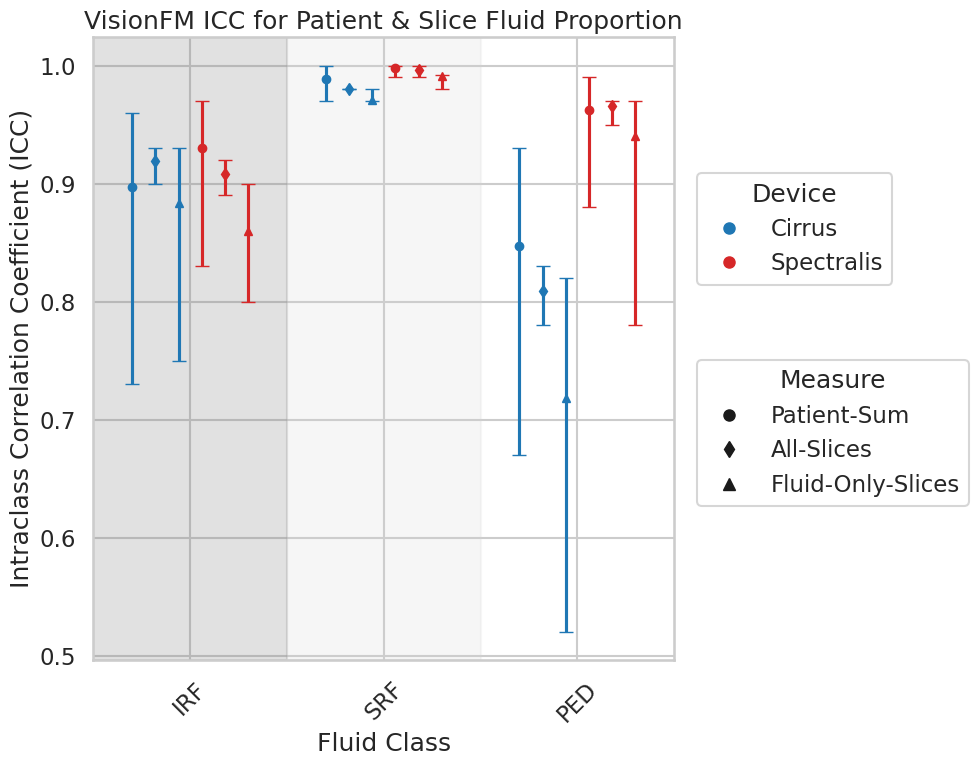

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

devices = sorted(metrics.keys())
classes = list(metrics[devices[0]]['slice_ref'].keys())
records = []
for ds in devices:
    # Patient-Sum
    pats     = metrics[ds]['patients']
    ref_sum  = np.vstack(metrics[ds]['sum_ref'])
    pred_sum = np.vstack(metrics[ds]['sum_pred'])
    for idx, cls in enumerate(classes):
        df = pd.DataFrame({
            'subject': np.repeat(pats, 2),
            'rater':   np.tile(['ref','vfm'], len(pats)),
            'value':   np.vstack([ref_sum[:,idx], pred_sum[:,idx]]).T.flatten()
        })
        tbl = pg.intraclass_corr(data=df, targets='subject',
                                 raters='rater', ratings='value').round(3)
        row = tbl.query("Type=='ICC2'").iloc[0]
        lo, hi = row['CI95%']
        records.append({
            'device': ds, 'class': cls, 'measure': 'Patient-Sum',
            'ICC': row['ICC'], 'lo': lo, 'hi': hi
        })
    # Slice-All & Slice-Fluid
    for cls in classes:
        ref_s  = np.array(metrics[ds]['slice_ref'][cls])
        pred_s = np.array(metrics[ds]['slice_pred'][cls])
        n = len(ref_s)
        for measure, mask in [('All-Slices', np.ones(n,bool)),
                              ('Fluid-Only-Slices', ref_s>0)]:
            if not mask.any():
                records.append({
                    'device': ds, 'class': cls, 'measure': measure,
                    'ICC': np.nan, 'lo': np.nan, 'hi': np.nan
                })
                continue
            df = pd.DataFrame({
                'subject': np.repeat(
                    [f"{ds}_slice_{i:03d}" for i in np.where(mask)[0]], 2),
                'rater': np.tile(['ref','vfm'], mask.sum()),
                'value': np.vstack([ref_s[mask], pred_s[mask]]).T.flatten()
            })
            tbl = pg.intraclass_corr(data=df, targets='subject',
                                     raters='rater', ratings='value').round(3)
            row = tbl.query("Type=='ICC2'").iloc[0]
            lo, hi = row['CI95%']
            records.append({
                'device': ds, 'class': cls, 'measure': measure,
                'ICC': row['ICC'], 'lo': lo, 'hi': hi
            })

df_plot = pd.DataFrame(records)

# Prep for plot
dfp = df_plot[df_plot['class']!='Background']  # Drop Background
devices = sorted(dfp['device'].unique())
classes = ['IRF','SRF','PED']
x       = np.arange(len(classes))
width   = 0.12

colors  = {'Cirrus':'tab:blue','Spectralis':'tab:red'}      # Device color map
markers = {'Patient-Sum':'o','All-Slices':'d','Fluid-Only-Slices':'^'}   # Measure markers map
cap = width * 0.4

sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12,8))

# shade IRF & SRF regions
ax.axvspan(-0.5,  0.5, color='dimgray',  alpha=0.2)
ax.axvspan( 0.5,  1.5, color='lightgray', alpha=0.2)

# plot
for di, ds in enumerate(devices):
    for mi, measure in enumerate(['Patient-Sum','All-Slices','Fluid-Only-Slices']):
        sub = dfp[(dfp.device==ds)&(dfp.measure==measure)]
        xi  = x + ((di*3 + mi) - 2.5)*width
        lo  = np.abs(sub.ICC - sub.lo)
        hi  = np.abs(sub.hi  - sub.ICC)
        ax.errorbar(
            xi, sub.ICC,
            yerr=[lo,hi],
            marker=markers[measure],
            color=colors[ds],
            ms=6, capsize=5, linestyle="none"
        )

# axes
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.set_xlabel("Fluid Class")
ax.set_ylabel("Intraclass Correlation Coefficient (ICC)")
ax.set_title("VisionFM ICC for Patient & Slice Fluid Proportion")
ax.set_xlim(-0.5, len(classes)-0.5) 

# legends
dev_handles = [Line2D([0],[0], marker='o', color=colors[ds], 
                      linestyle='none', markersize=8) for ds in devices]
dev_labels  = [f"{ds}" for ds in devices]
leg1 = ax.legend(dev_handles, dev_labels, title="Device",
                 loc='upper left', bbox_to_anchor=(1.02, 0.8))

meas_handles = [Line2D([0],[0], marker=markers[m], color='k',
                       linestyle='none', markersize=8) 
                for m in ['Patient-Sum','All-Slices','Fluid-Only-Slices']]
meas_labels  = ['Patient‐Sum', 'All-Slices','Fluid-Only-Slices']
leg2 = ax.legend(meas_handles, meas_labels, title="Measure",
                 loc='upper left', bbox_to_anchor=(1.02, 0.5))
ax.add_artist(leg1) 

plt.tight_layout(rect=[0,0,0.85,1])
plt.show()